# Laboratorio de regresión logística

|                |   |
:----------------|---|
| **Nombre**     |Sofia Anaya Palafox|
| **Fecha**      |8 Marzo 2026|
| **Expediente** |738594   |

La regresión logística es una herramienta utilizada para predecir respuestas cualitativas. Al igual que la regresión lineal, es un método sencillo que sirve como un punto de partida para técnicas más avanzadas. Por ejemplo, lo que se conoce como *redes neuronales* o *red de perceptrones multicapa* no es más que una estructura de regresiones logísticas que se alimentan entre sí.

1. Descarga el archivo de créditos y carga los datos (Default.csv). Utiliza `pandas`.

In [7]:
import pandas as pd
obj = pd.read_csv('/content/Default.csv')

2. Utiliza el comando `obj.head()`, donde `obj` es el nombre que le diste a los datos del archivo.

In [5]:
obj.head()

,default,student,balance,income
0,No,No,729.526495,44361.625074
1,No,Yes,817.180407,12106.134700
2,No,No,1073.549164,31767.138950
3,No,No,529.250605,35704.493940
4,No,No,785.655883,38463.495880


El comando head arroja los primeras *n* líneas (por defecto 5) de los datos que están en el DataFrame.

3. Utiliza el comando `obj.describe()`.

In [6]:
obj.describe()

,balance,income
count,10000.000000,10000.000000
mean,835.374886,33516.981876
std,483.714985,13336.639563
min,0.000000,771.967729
25%,481.731105,21340.462903
50%,823.636973,34552.644802
75%,1166.308386,43807.729275
max,2654.322576,73554.233500


El comando describe toma las columnas que tienen datos numéricos y saca datos estadísticos comunes:
- *n*
- media
- desviación estándar
- valor mínimo
- primer cuartil
- mediana
- tercer cuartil
- valor máximo

3. Vistos estos datos, ¿qué columnas existen en el DataFrame? ¿Qué tipo de datos contienen?

**default**: En esta columna solo existe Sí y No

**student**: En esta columna solo existe Sí y No

**balance**: Contiene números específicos

**income**: Esta igual


4. Configura el tipo de dato de las columnas `default` y `student` para cambiarlos a variables categóricas.

`data[columna] = data[columna].astype("category")`

In [8]:
obj['default'] = obj['default'].astype('category')

In [9]:
obj['student'] = obj['student'].astype('category')

Imagina que trabajas en un banco y que se te entregan estos datos. Tu objetivo es crear un modelo que ayude a predecir si una persona que solicita un crédito lo va a pagar. Exploremos los datos un poco más antes de crear un modelo.

Veamos primero cómo es la distribución de los valores cuando una persona dejó de pagar y cuando siguió pagando. `Default` es el término utilizado para cuando una persona dejó de pagar.

5. Crea una gráfica de caja para las columnas `income` y `balance`, con los datos agrupados con la columna `default`. Utiliza el comando `obj.boxplot(column=____, by=_____)`

<Axes: title={'center': 'income'}, xlabel='default'>

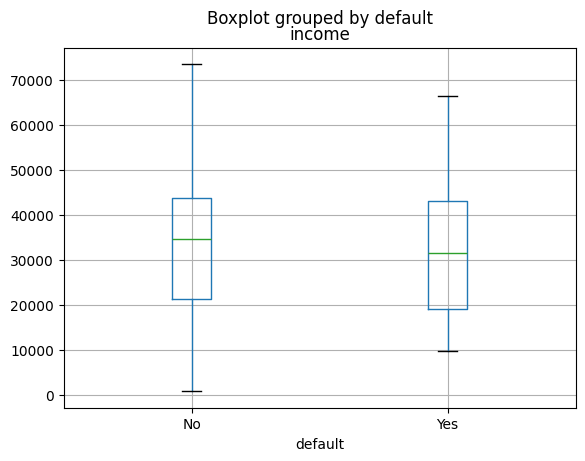

In [13]:
obj.boxplot(column='income', by='default')

<Axes: title={'center': 'balance'}, xlabel='default'>

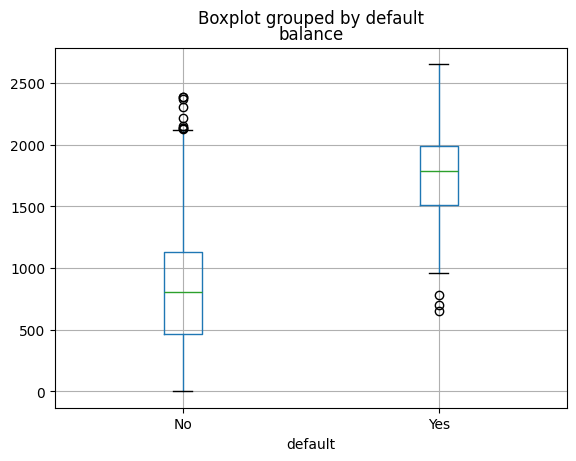

In [14]:
obj.boxplot(column='balance', by='default')

6. Crea una gráfica de dispersión donde el eje *x* sea la columna `balance` y el eje *y* la columna `income`. Utiliza el comando `obj.plot.scatter(x, y, c="default", colormap="PiYG_r", alpha=0.5)`.

In [23]:
x = 'balance'
y = 'income'

<Axes: xlabel='balance', ylabel='income'>

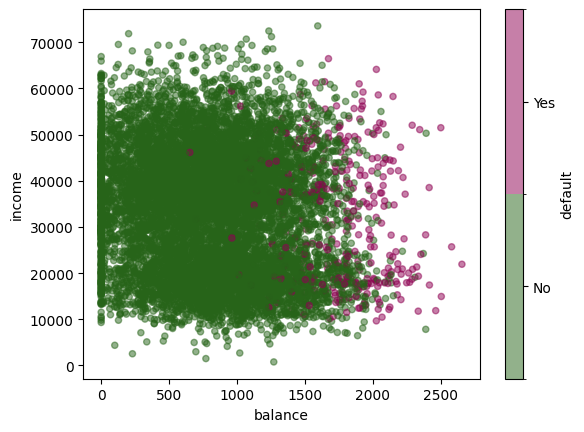

In [24]:
obj.plot.scatter(x, y, c="default", colormap="PiYG_r", alpha=0.5)

La regresión (lineal o logística) se usa para encontrar una línea que ajuste los datos para tomar una decisión. La línea que buscamos en regresión logística es aquella que nos ayude a separar las diferentes categorías.

<img style="float: left; " src="https://www.baeldung.com/wp-content/uploads/sites/4/2023/10/decision_boundary_curve.jpg" width="400px" />


## Regresión logística simple

Creemos un modelo simple donde sólo utilizamos una de los factores para predecir una respuesta. Quiero conocer la probabilidad de que una persona deje de pagar su crédito dado el balance que tiene en su cuenta.

$$ P(\text{default}=\text{Yes}|\text{balance}) $$

Por el momento la columna default no contiene valores numéricos, por lo que hay que transformar los datos. Como default es nuestra variable de respuesta (lo que queremos predecir) podemos nombrarla *y*.

Ejecuta el código `y = obj["default"] == "Yes"`. Extrae el factor `balance` en una variable *x*.

In [25]:
y = obj["default"] == "Yes"

In [27]:
x = obj["balance"]

Crea un gráfico de dispersión donde el eje *x* sea `balance` y el eje *y* sea `default` transformado.

Text(0.5, 1.0, 'Default vs. Balance')

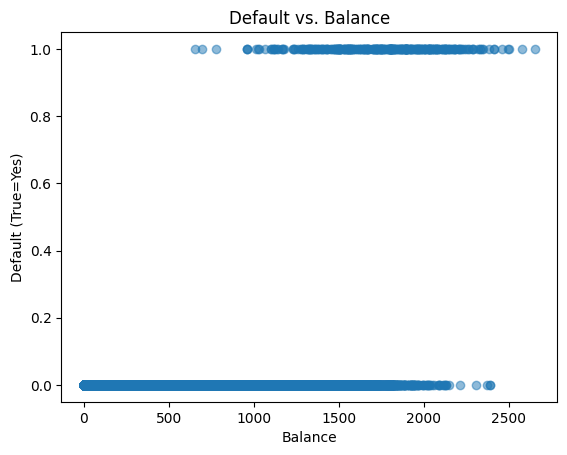

In [28]:
import matplotlib.pyplot as plt
plt.scatter(x, y, alpha=0.5)
plt.xlabel('Balance')
plt.ylabel('Default (True=Yes)')
plt.title('Default vs. Balance')

La línea que utilizaremos para predecir la probabilidad es:

$$ p(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}} $$

Para nuestro ejemplo de pagos y balance:

$$ P(\text{default}=1|\text{balance}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance})}} $$

Buscamos maximizar la probabilidad de que el modelo tome decisiones correctas. Es decir, que cuando `default` fue verdadero, que la predicción sea 100%, y que cuando `default` fue falso que la predicción sea 0%.

$$ \Pi_{i:y_i=1} p(x_i) \Pi_{i':y_{i'}} (1-p(x_{i'})) $$

La función de costo ya simplificada es la siguiente:

$$ J(\vec{\beta}) = -  \sum_{i=1}^n{[y_i \ln{(\hat{p}(x_i))} + (1-y_i)\ln{(1 - \hat{p}(x_i))}]}$$

Utiliza la clase `LogisticRegression` del módulo `linear_model` de la librería `sklearn` para estimar los parámetros del modelo.

In [60]:
from sklearn.linear_model import LogisticRegression
import numpy as np

x_reshaped = x.values.reshape(-1, 1)

model = LogisticRegression(solver='liblinear')
model.fit(x_reshaped, y)

LogisticRegression(solver='liblinear')

Muchos aspectos de la regresión logística son similares a la regresión lineal. Podemos medir la precisión de nuestros estimados calculando sus errores estándar. El objetivo de calcular estos errores es asegurar que hay una relación estadísticamente significativa entre el factor y la variable de respuesta.

Los errores estándar se obtienen con el siguiente procedimiento:

1. Calcula las predicciones utilizando los $\beta_0$ y $\beta_1$ encontrados.

In [45]:
# Extrae coeficientes e interceptos
beta_0 = model.intercept_[0]
beta_1 = model.coef_[0][0]

betas = np.array([beta_0, beta_1])

probabilities = model.predict_proba(x_reshaped)[:, 1]

2. Idealmente la probabilidad debería ser 100% o 0%. Si alguna predicción no fue absoluta significa que hay incertidumbre. Calcula $p(1-p)$ para todas tus predicciones.

In [62]:
p_times_1_minus_p = probabilities * (1 - probabilities)

X_design = np.column_stack((np.ones(len(x_reshaped)), x_reshaped))

3. Crea una matriz vacía y llena la diagonal con las probabilidades encontradas.

`V = np.diagflat(*p(1-p)*)`

In [61]:
V = np.diagflat(p_times_1_minus_p)

4. Calcula la matriz de covarianza. (Dado que X es la matriz que contiene todos los factores)

`cov = np.linalg.inv(X.T @ V @ X)`

In [63]:
cov = np.linalg.inv(X_design.T @ V @ X_design)

5. Los valores en la diagonal de la matriz de covarianza corresponden a la varianza de los factores. Utiliza los valores de la diagonal para calcular el error estándar.

`se = np.sqrt(np.diag(cov))`

In [64]:
se = np.sqrt(np.diag(cov))

Ahora, revisemos si los estimados de nuestros coeficientes demuestran que hay una relación significativa entre los factores y la respuesta.

Calculamos el estadístico *z*

$$ z_j = \frac{\hat{\beta_j}}{\text{SE}(\hat{\beta_j})} $$

In [65]:
z_statistic = betas / se
print(f"Z-statistics: {z_statistic}")

Z-statistics: [-31.21334233  25.30609797]


Utilizamos el estadístico *z* para encontrar el *p-value*.

`from scipy.stats import norm`

`p_value = 2 * (1 - norm.cdf(abs(z_statistic)))`

In [66]:
from scipy.stats import norm

p_value = 2 * (1 - norm.cdf(abs(z_statistic)))
print(f"P-values: {p_value}")

P-values: [0. 0.]


¿Es significativa la relación de los factores con la variable de respuesta?

como los valores son 0, hay mucha evidencia para decir que balance es significativoo para predecir los creditos

Repite el procedimiento con el factor `student`.
1. Transforma el factor de {"Yes", "No"} a {1, 0}.
2. Estima los coeficientes.
3. Calcula el error estándar de tus estimaciones.
   1. Usa tu modelo para encontrar $\hat{p}(X)$
   2. Calcula el error $p(1-p)$
   3. Calcula la matriz de covarianza
   4. Extrae el error estándar
5. Argumenta si los factores son significativos utilizando el *p-value*.
   1. Utiliza el error estándar para calcular el estadístico *z*
   2. Calcula el *p-value*
   3. ¿Son significativos?


In [67]:
# Transforma el factor 'student' de {'Yes', 'No'} a {1, 0}.
x_student_bool = (obj["student"] == "Yes")

x_student_reshaped = x_student_bool.values.reshape(-1, 1)

# Estima los coeficientes.
model_student = LogisticRegression(solver='liblinear')
model_student.fit(x_student_reshaped, y)

LogisticRegression(solver='liblinear')

In [68]:

probabilities_student = model_student.predict_proba(x_student_reshaped)[:, 1]

# Calcular el error p(1-p)
p_times_1_minus_p_student = probabilities_student * (1 - probabilities_student)

# Matriz de diseño X (con término de intercepto)
X_design_student = np.column_stack((np.ones(len(x_student_reshaped)), x_student_reshaped))

In [55]:
# Matriz de covarianza
V_student = np.diagflat(p_times_1_minus_p_student)
cov_student = np.linalg.inv(X_design_student.T @ V_student @ X_design_student)

# error estándar
se_student = np.sqrt(np.diag(cov_student))

# Extrae los coeficientes beta
beta_0_student = model_student.intercept_[0]
beta_1_student = model_student.coef_[0][0]
betas_student = np.array([beta_0_student, beta_1_student])

# Utiliza el error estándar para calcular el estadístico z
z_statistic_student = betas_student / se_student
print(f"Z-statistics for student model: {z_statistic_student}")

# Calcula el p-value
from scipy.stats import norm
p_value_student = 2 * (1 - norm.cdf(abs(z_statistic_student)))
print(f"P-values for student model: {p_value_student}")

# Son significativos?
print("Are the factors in the student model significant?:")
if any(p < 0.05 for p in p_value_student):
    print("Yes, at least one factor is significant (p-value < 0.05).")
else:
    print("No, the factors are not significant (p-value >= 0.05).")

Z-statistics for student model: [-49.72950489   3.33442099]
P-values for student model: [0.         0.00085477]
Are the factors in the student model significant?:
Yes, at least one factor is significant (p-value < 0.05).


## Regresión logística múltiple

Considera ahora el caso de múltiples factores. Intentemos predecir si la persona dejará de pagar su crédito utilizando toda la información que tenemos disponible. I.e.

$$ P(\text{default}=1|\text{balance}, \text{income}, \text{student}) = \frac{1}{1 + e^{-(\beta_0 + \beta_1  \text{balance} + \beta_2 \text{income} + \beta_3 \text{student})}} $$

1. Utiliza `LogisticRegression` para estimar los coeficientes.
2. Calcula el error estándar de tus estimaciones.
3. Argumenta si los factores son significativos utilizando el *p-value*.

In [56]:
obj['student_numeric'] = x_student_bool.astype(int)
X = obj[['balance', 'income', 'student_numeric']]

In [69]:
model_multi = LogisticRegression(solver='liblinear')
model_multi.fit(X, y)

# Extrae coeficientes e interceptos
beta_0_multi = model_multi.intercept_[0]
betas_multi = model_multi.coef_[0]

print(f"Intercept (beta_0): {beta_0_multi}")
print(f"Coefficients (balance, income, student_numeric): {betas_multi}")

Intercept (beta_0): -1.9417968062452366e-06
Coefficients (balance, income, student_numeric): [ 4.07583928e-04 -1.25881515e-04 -2.51031353e-06]


In [70]:
import numpy as np

probabilities_multi = model_multi.predict_proba(X)[:, 1]

p_times_1_minus_p_multi = probabilities_multi * (1 - probabilities_multi)

X_design_multi = np.column_stack((np.ones(len(X)), X))

V_multi = np.diagflat(p_times_1_minus_p_multi)

cov_multi = np.linalg.inv(X_design_multi.T @ V_multi @ X_design_multi)

se_multi = np.sqrt(np.diag(cov_multi))

print(f"Standard Errors (Intercept, balance, income, student_numeric): {se_multi}")

Standard Errors (Intercept, balance, income, student_numeric): [2.49788522e-01 9.54244495e-05 7.63451861e-06 1.44563335e-01]


In [59]:
from scipy.stats import norm

betas_all_multi = np.concatenate(([beta_0_multi], betas_multi))

z_statistic_multi = betas_all_multi / se_multi
print(f"Z-statistics (Intercept, balance, income, student_numeric): {z_statistic_multi}")

p_value_multi = 2 * (1 - norm.cdf(abs(z_statistic_multi)))
print(f"P-values (Intercept, balance, income, student_numeric): {p_value_multi}")

Z-statistics (Intercept, balance, income, student_numeric): [-7.77376316e-06  4.27127356e+00 -1.64884679e+01 -1.73648009e-05]
P-values (Intercept, balance, income, student_numeric): [9.99993797e-01 1.94359815e-05 0.00000000e+00 9.99986145e-01]


Resumen

Intercepto: El valor p para el intercepto es cercano a 1. O sea no es significativo en este modelo.

Balance: El valor p para 'balance' es 0.0000194. es altamente significativo

Income: El valor p para 'income' es aproximadamente 0, por lo tanto, es muy significativo para el modelo

Student (Numérico): El valor p para 'student_numeric' es aproximadamente 9.Por lo tanot, no ayuda.

En conclusión, 'balance' e 'income' son predictores muy importantes del incumplimiento crediticio, mientras que la condición de 'estudiante' y el intercepto no.



¿Cómo sabemos qué tan bueno es el modelo? Hay cuatro posibles casos para un problema de clasificación simple:
- Era sí y se predijo sí. (Verdadero positivo **TP**)
- Era sí y se predijo no. (Falso negativo **FN**)
- Era no y se predijo sí. (Falso positivo **FP**)
- Era no y se predijo no. (Verdadero negativo **TN**)

De esos cuatro casos hay dos donde el modelo es correcto y dos donde el modelo no es correcto.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*IuymDnZpRlkat0qejE26Nw.png)

**1. Menciona dos ejemplos donde consideres que un falso positivo sea un peor resultado que un falso negativo.**


1. Diagnóstico de una enfermedad grave con un tratamiento muy agresivo

2. Que un correo muy importante se vea como spam


**2. Menciona dos ejemplos donde consideres que un falso negativo sea un peor resultado que un falso positivo.**

1. Que piensen que un pasajero en un aeropuerto trae un arma

2. Que los sensores de humo de un edificio se prendan sin haber un incendio

## Referencia

James, G., Witten, D., Hastie, T., Tibshirani, R.,, Taylor, J. (2023). An Introduction to Statistical Learning with Applications in Python. Cham: Springer. ISBN: 978-3-031-38746-3